# Grover's Search Algorithm using Qiskit

## Overview

Grover's Algorithm is a quantum search algorithm that finds a desired item in an unsorted database significantly faster than classical methods.

Example:

Suppose we have:

00
01
10
11

and we want to find:

11

Classically:

Worst Case:
4 searches

Average:
2 searches

Quantum:

Approximately √N searches

For N=4:
Only 1 Grover iteration is needed.

---

## Concepts Covered

- Superposition
- Oracle
- Phase Inversion
- Diffuser
- Amplitude Amplification
- Measurement

---

## Visualizations

- Circuit Diagrams
- Statevectors
- State City Plots
- Bloch Sphere Visualizations
- Probability Histograms
- Oracle Visualization
- Diffuser Visualization
- Amplitude Amplification Charts
- Classical vs Quantum Comparison

---

## Installation

pip install qiskit qiskit-aer matplotlib pylatexenc

Author: Muhammad Saad

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=136cd0efaf3af929bd76bef65e105cd749add108085149bfaa7f50d99eab33bc
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit.visualization import (
    plot_histogram,
    plot_state_city,
    plot_bloch_multivector
)

from qiskit_aer import AerSimulator

from IPython.display import display

In [3]:
def visualize_state(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    probs = state.probabilities_dict()

    print("\nProbabilities:")
    for k,v in probs.items():
        print(f"{k}: {v:.4f}")

    display(plot_state_city(state))
    display(plot_bloch_multivector(state))

    return state

# Grover's Search Algorithm

Goal:

Find a desired item in an unsorted database.

Database:

00
01
10
11

Target:

11

Classically:

Need multiple guesses.

Quantum:

Amplifies the probability of the correct answer.

In [4]:
# Search Target

target = "11"

print()
print("DATABASE")

database = ["00","01","10","11"]

for item in database:
    print(item)

print()
print("TARGET ITEM")
print(target)


DATABASE
00
01
10
11

TARGET ITEM
11


# Oracle

The Oracle knows the target state.

It does NOT reveal it.

It only flips the phase:

|w⟩ → -|w⟩

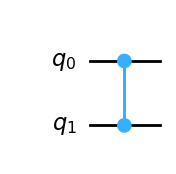

In [6]:
def grover_oracle():

    oracle = QuantumCircuit(2)

    oracle.cz(0,1)

    return oracle

oracle = grover_oracle()

display(oracle.draw("mpl"))

# Diffuser

The diffuser reflects amplitudes around the average.

This increases the probability of the marked state.

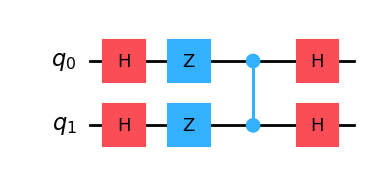

In [7]:
def diffuser():

    qc = QuantumCircuit(2)

    qc.h([0,1])

    qc.z([0,1])

    qc.cz(0,1)

    qc.h([0,1])

    return qc

display(diffuser().draw("mpl"))

Uniform Superposition


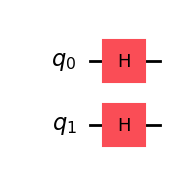


Statevector:
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))

Probabilities:
00: 0.2500
01: 0.2500
10: 0.2500
11: 0.2500


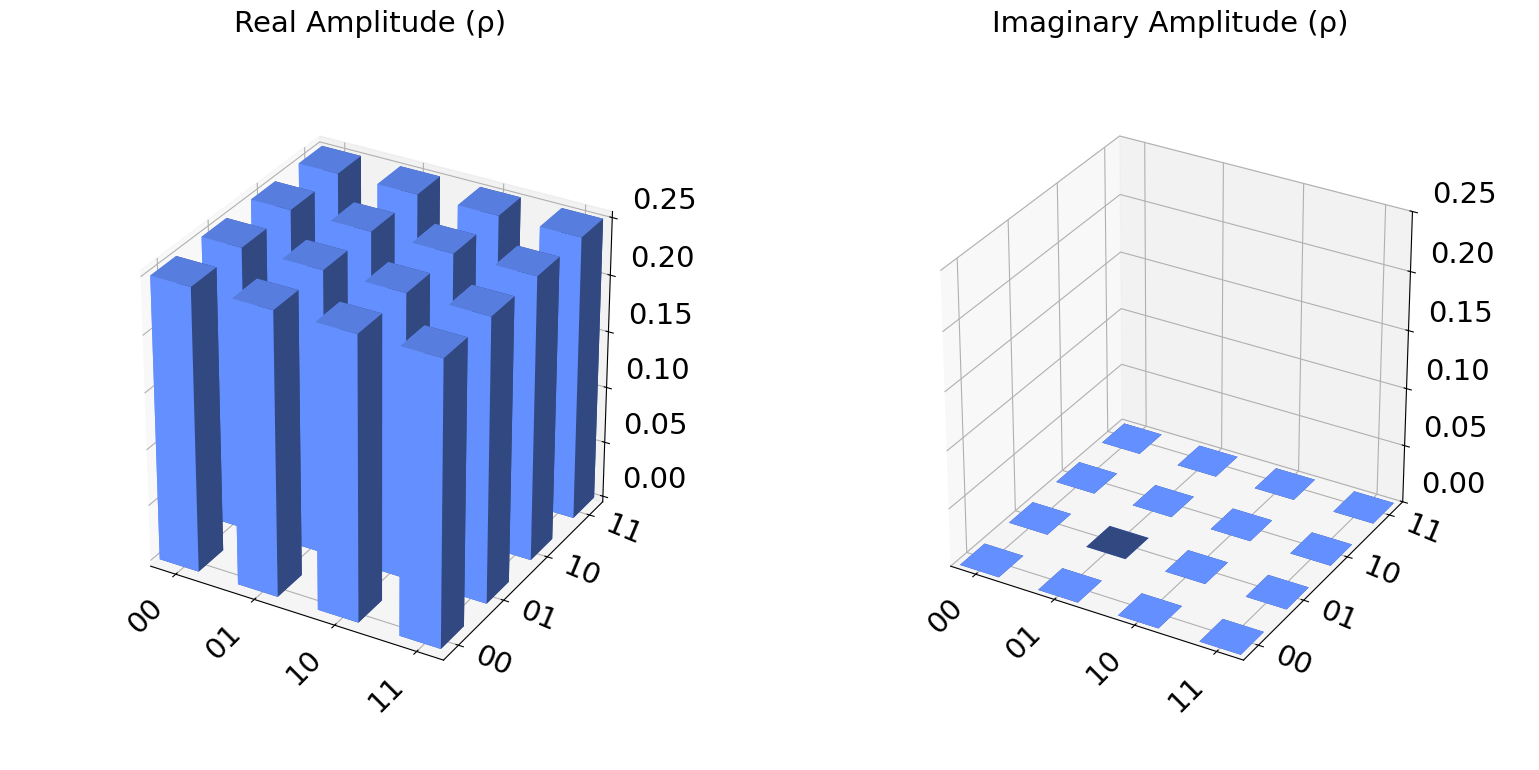

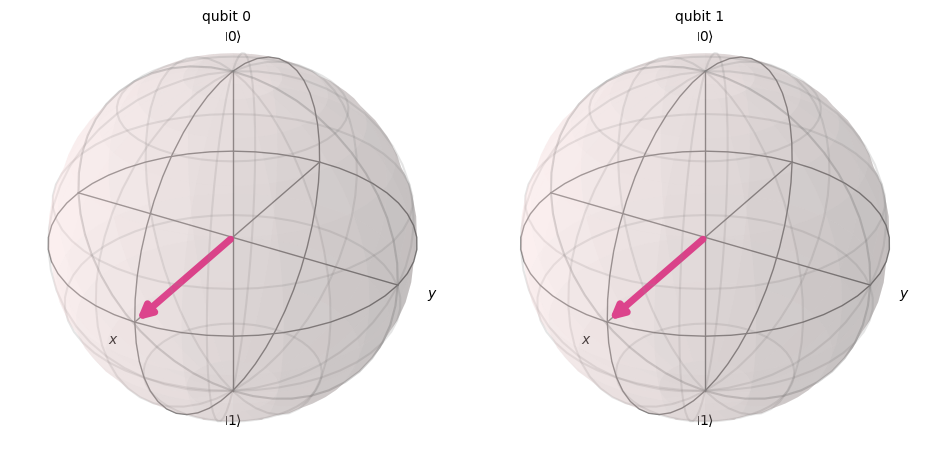

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


In [8]:
qc = QuantumCircuit(2)

qc.h([0,1])

visualize_state(
    qc,
    "Uniform Superposition"
)

After Oracle


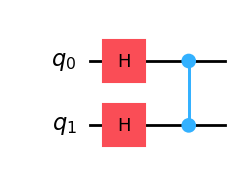


Statevector:
Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))

Probabilities:
00: 0.2500
01: 0.2500
10: 0.2500
11: 0.2500


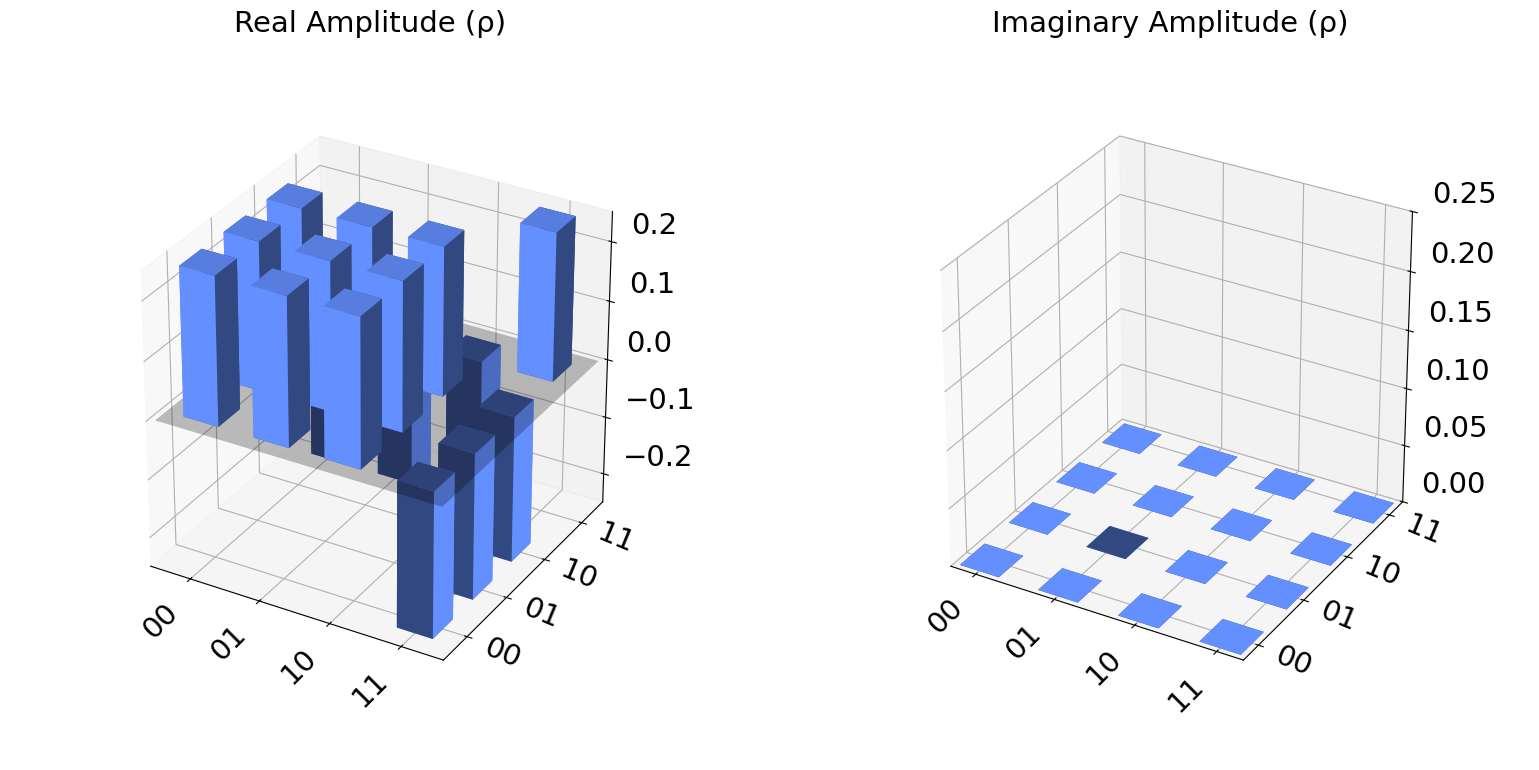

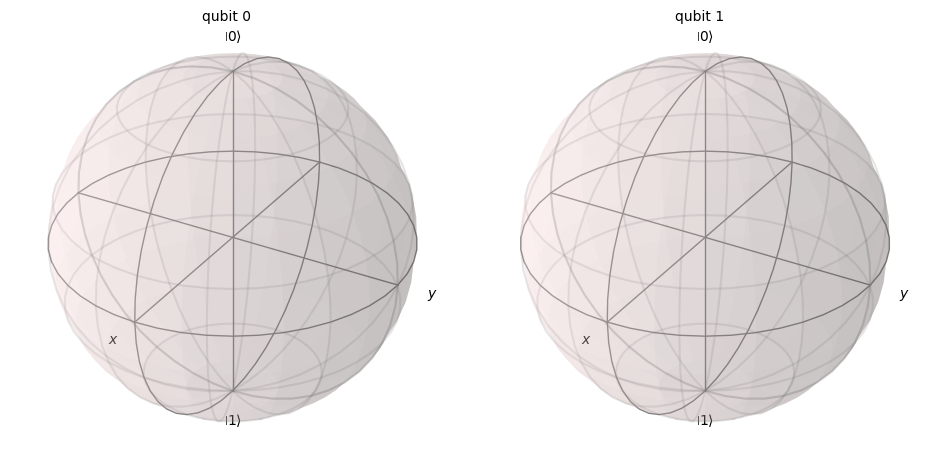

Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


In [9]:
qc = QuantumCircuit(2)

qc.h([0,1])

qc.compose(
    grover_oracle(),
    inplace=True
)

visualize_state(
    qc,
    "After Oracle"
)

11 receives a phase flip.

Probabilities stay same.

Only sign changes.

After Grover Iteration


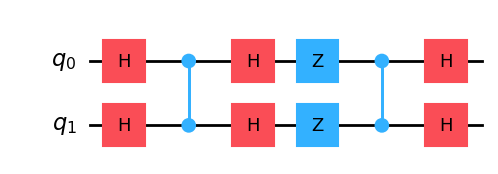


Statevector:
Statevector([1.26316153e-34+0.j, 2.36158002e-17+0.j, 9.52420783e-18+0.j,
             1.00000000e+00+0.j],
            dims=(2, 2))

Probabilities:
00: 0.0000
01: 0.0000
10: 0.0000
11: 1.0000


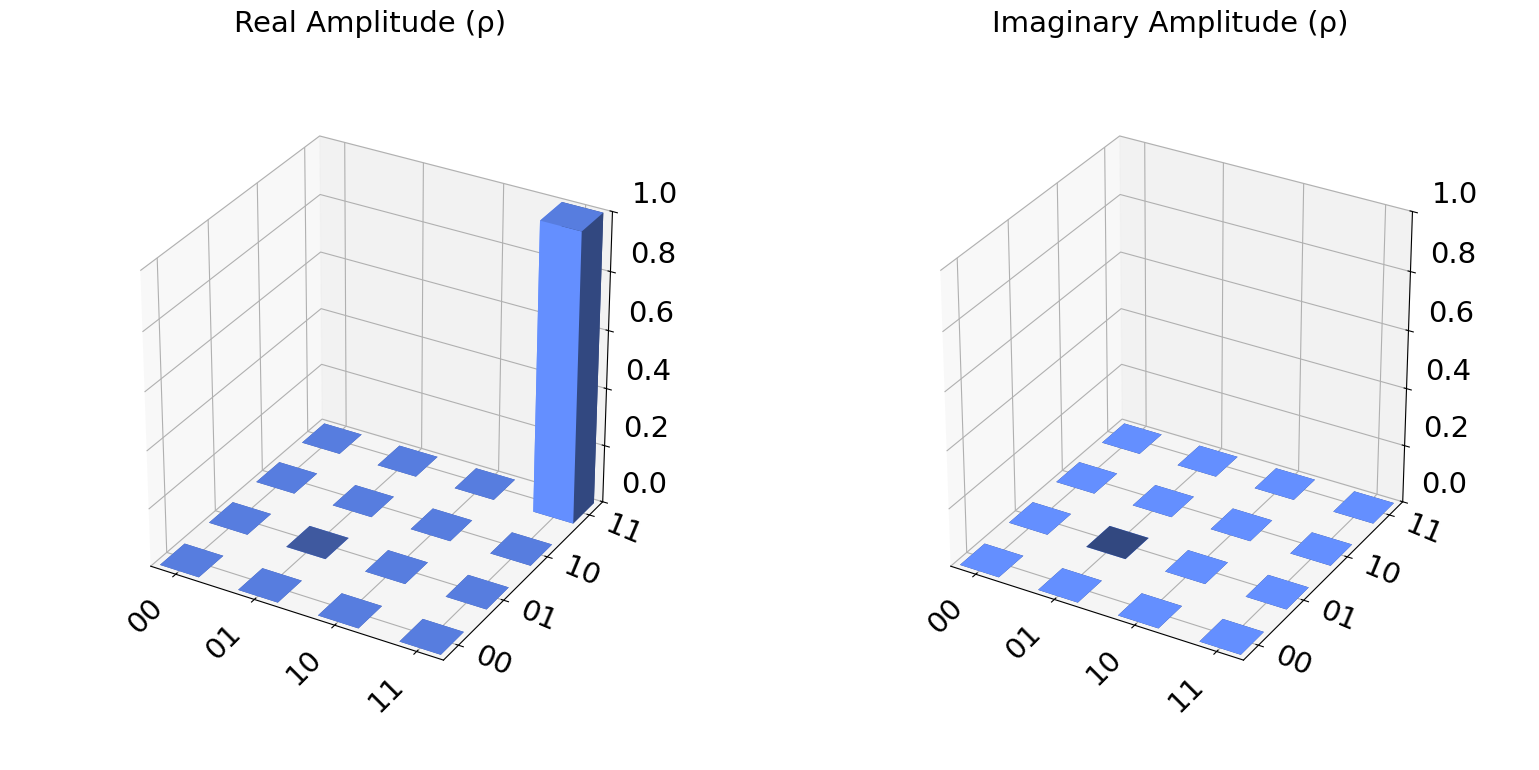

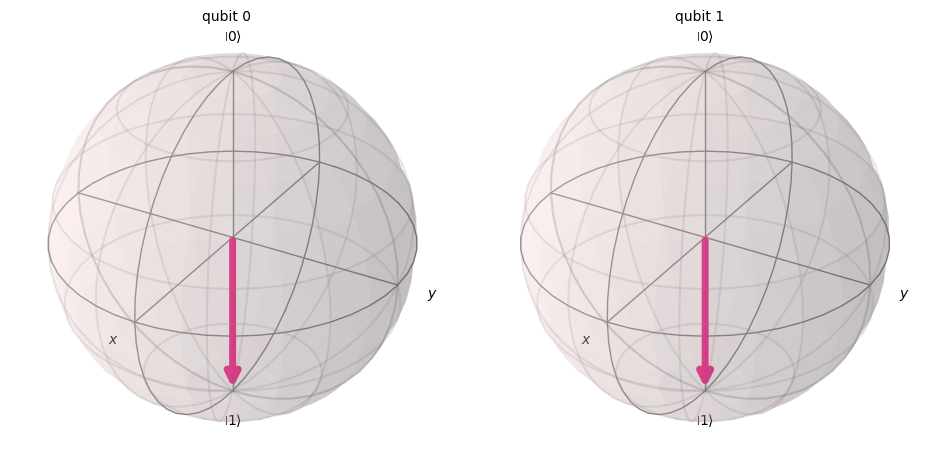

Statevector([1.26316153e-34+0.j, 2.36158002e-17+0.j, 9.52420783e-18+0.j,
             1.00000000e+00+0.j],
            dims=(2, 2))


In [11]:
# After Diffuser

qc = QuantumCircuit(2)

qc.h([0,1])

qc.compose(
    grover_oracle(),
    inplace=True
)

qc.compose(
    diffuser(),
    inplace=True
)

visualize_state(
    qc,
    "After Grover Iteration"
)

In [12]:
state = Statevector.from_instruction(qc)

print()
print("AMPLITUDE ANALYSIS")

for basis,amp in state.to_dict().items():

    print(
        basis,
        "Amplitude =",
        round(abs(amp),4)
    )


AMPLITUDE ANALYSIS
00 Amplitude = 0.0
01 Amplitude = 0.0
10 Amplitude = 0.0
11 Amplitude = 1.0


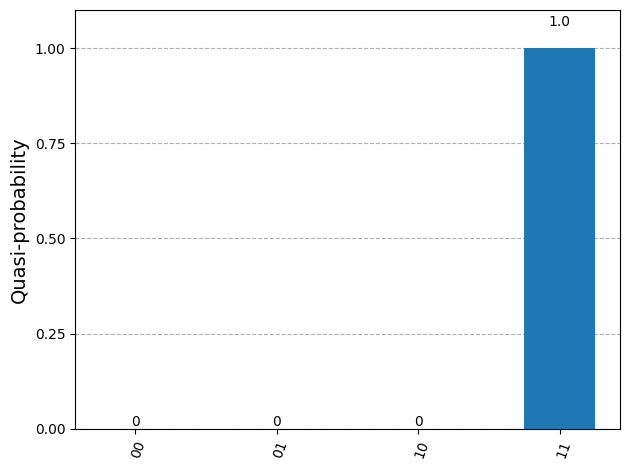

In [13]:
probs = state.probabilities_dict()

display(
    plot_histogram(probs)
)

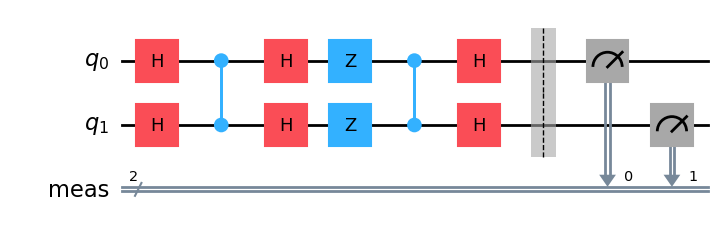

In [14]:
qc_measure = qc.copy()

qc_measure.measure_all()

display(qc_measure.draw("mpl"))

{'11': 1000}


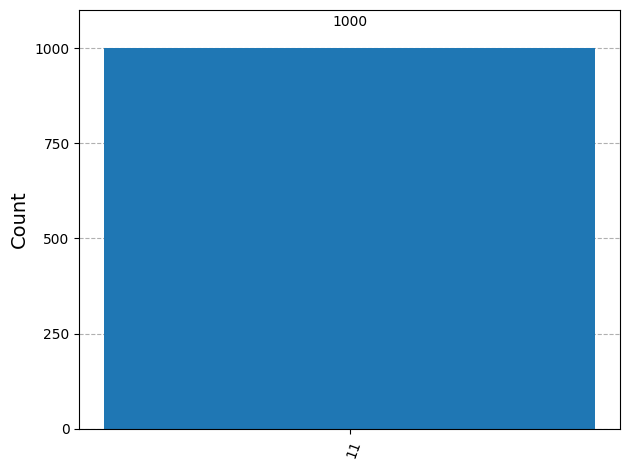

In [15]:
sim = AerSimulator()

result = sim.run(
    qc_measure,
    shots=1000
).result()

counts = result.get_counts()

print(counts)

display(
    plot_histogram(counts)
)

In [16]:
print("="*60)
print("GROVER SEARCH REPORT")
print("="*60)

print()

print("Database:")

for item in database:
    print(item)

print()

print("Target Item:")
print(target)

print()

print("Oracle marked the target.")

print()

print("Diffuser amplified its probability.")

print()

print("Measurement Result:")

print(max(counts,key=counts.get))

print()

print("SUCCESS ✓")

GROVER SEARCH REPORT

Database:
00
01
10
11

Target Item:
11

Oracle marked the target.

Diffuser amplified its probability.

Measurement Result:
11

SUCCESS ✓


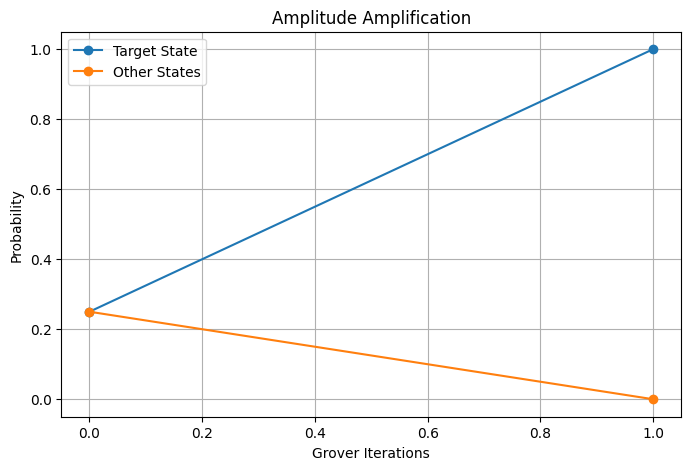

In [17]:
iterations = [0,1]

target_probabilities = [
    0.25,
    1.00
]

other_probabilities = [
    0.25,
    0.00
]

plt.figure(figsize=(8,5))

plt.plot(
    iterations,
    target_probabilities,
    marker='o',
    label='Target State'
)

plt.plot(
    iterations,
    other_probabilities,
    marker='o',
    label='Other States'
)

plt.xlabel("Grover Iterations")
plt.ylabel("Probability")

plt.title("Amplitude Amplification")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
print("="*60)
print("MISSION REPORT")
print("="*60)

print()

print("Target Hidden Item :",target)

print("Quantum Search Found:",max(counts,key=counts.get))

print()

print("Classical Complexity : O(N)")
print("Quantum Complexity   : O(√N)")

print()

print("Mission Successful ✓")

MISSION REPORT

Target Hidden Item : 11
Quantum Search Found: 11

Classical Complexity : O(N)
Quantum Complexity   : O(√N)

Mission Successful ✓
